# Stage 2A: Representation Experiment

**Тонкий UI-слой** — оркестрация эксперимента Stage 2A (C0 / C1 / C2).

Вся бизнес-логика вынесена в `d4/analysis/` и CLI runner (`d4/tests/mini_llm_run.py`).  
Ноутбук не содержит вычислительной логики — только вызовы модулей и subprocess.

| Секция | Назначение |
|--------|-----------|
| 1 | Run Config |
| 2 | Preflight |
| 3 | Execute (subprocess CLI per mode) |
| 4 | Load Reports |
| 5 | Compare C0/C1/C2 |
| 6 | Plots |
| 7 | Decision Memo |
| 8 | Artifact Index |

## 1. Run Config

In [26]:
import sys
import logging
from pathlib import Path
from datetime import datetime

# Включаем logging, чтобы warnings из d4.analysis.loaders и других модулей
# были видны прямо в stdout ячейки (иначе "пустой DataFrame" выглядит как
# "ничего не произошло").
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s %(name)s: %(message)s",
    force=True,
)

# ──────────────────────────────────────────────
# Resolver STUDY_ROOT — не зависит от cwd ядра.
# Проверяем по маркерам: d4/configs/experiment.yaml и .venv/bin/python.
# ──────────────────────────────────────────────
_CANDIDATES = [
    Path("/Users/kazdoraw/developer/med-agent/study"),
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
    Path.cwd().parent.parent.parent,
]

STUDY_ROOT = None
for _p in _CANDIDATES:
    if (_p / "d4" / "configs" / "experiment.yaml").exists() and (_p / ".venv" / "bin" / "python").exists():
        STUDY_ROOT = _p.resolve()
        break

assert STUDY_ROOT is not None, (
    "Не удалось определить STUDY_ROOT: ни один кандидат не содержит "
    "d4/configs/experiment.yaml и .venv/bin/python"
)

if str(STUDY_ROOT) not in sys.path:
    sys.path.insert(0, str(STUDY_ROOT))

# Если kernel стартовал из другой копии проекта (например, ai-core/apps/agent-llm),
# `d4` мог попасть в sys.modules ДО нашего insert(0, STUDY_ROOT). Тогда from d4...
# возьмёт закэшированную ai-core-копию без наших правок. Чистим кэш, чтобы
# следующий импорт подхватил d4 из STUDY_ROOT.
for _mod in [m for m in sys.modules if m == "d4" or m.startswith("d4.")]:
    del sys.modules[_mod]

from d4.analysis.artifacts import make_run_paths, list_run_artifacts, latest_run_id
from d4.analysis.preflight import run_preflight
from d4.analysis.loaders import load_reports, load_rank_analysis
from d4.analysis.representation_compare import (
    build_retrieval_table, build_deterministic_table, evaluate_gate, rank_modes,
)
from d4.analysis.plots import (
    plot_retrieval_comparison, plot_quality_comparison, plot_mode_deltas, plot_rank_shift,
)
from d4.analysis.reporting import generate_stage2_memo
from d4.config import load_config

# Sanity-check: d4 действительно импортировался из STUDY_ROOT.
import d4 as _d4
_d4_path = Path(_d4.__file__).resolve().parent
assert _d4_path == (STUDY_ROOT / "d4"), (
    f"d4 импортирован из {_d4_path}, ожидалось {STUDY_ROOT / 'd4'}. "
    "Вероятно, в sys.path есть другая копия проекта. Сделайте Kernel → Restart."
)

# ──────────────────────────────────────────────
# Параметры прогона (единственное место настройки)
# ──────────────────────────────────────────────
# RUN_MODE:
#   "run_new"          — запустить LLM-прогон заново, RUN_ID = текущий timestamp.
#   "analyze_existing" — только анализ существующего прогона, subprocess-ячейка
#                         пропускается. RUN_ID должен быть явно указан
#                         (или None → возьмём latest_run_id()).
RUN_MODE = "analyze_existing"   # "run_new" | "analyze_existing"

MODES = ["plain", "contextual", "llm_enriched"]
EVAL_SET = "full_dev"          # "pilot" | "full_dev" | "smoke" | "hard" | "blind"
USE_EXPERIMENTAL = False

# RUN_ID — явный id прогона. Для analyze_existing обязателен (или None → latest).
# Для run_new игнорируется и перезаписывается текущим timestamp'ом.
RUN_ID_EXPLICIT = "20260419_235319"   # или None → latest_run_id()

assert RUN_MODE in ("run_new", "analyze_existing"), (
    f"Невалидный RUN_MODE={RUN_MODE!r}. Допустимые: 'run_new' | 'analyze_existing'"
)

if RUN_MODE == "run_new":
    RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
else:
    RUN_ID = RUN_ID_EXPLICIT or latest_run_id()
    assert RUN_ID is not None, (
        "RUN_MODE='analyze_existing', но RUN_ID_EXPLICIT=None и нет ни одного "
        "существующего run в outputs/runs/. Укажите RUN_ID_EXPLICIT явно."
    )

# Маппинг EVAL_SET → CLI-флаг и run_name для loaders
_EVAL_SET_CONFIG = {
    "pilot":    {"flags": ["--pilot"],    "run_name": "pilot_dev_30",
                 "eval_path": "d4/outputs/pilot_dev_30.yaml"},
    "full_dev": {"flags": ["--full-dev"], "run_name": "full_dev",
                 "eval_path": "d4/data/eval_set_dev_v2.yaml"},
    "smoke":    {"flags": [],             "run_name": "smoke",
                 "eval_path": "d4/tests/mini_eval_set.yaml"},
    "hard":     {"flags": ["--hard"],     "run_name": "hard",
                 "eval_path": "d4/tests/mini_eval_set_hard.yaml"},
    "blind":    {"flags": ["--blind"],    "run_name": "blind",
                 "eval_path": "d4/tests/blind_hard_holdout.yaml"},
}
assert EVAL_SET in _EVAL_SET_CONFIG, (
    f"Невалидный EVAL_SET='{EVAL_SET}'. "
    f"Допустимые: {list(_EVAL_SET_CONFIG.keys())}"
)
RUN_NAME = _EVAL_SET_CONFIG[EVAL_SET]["run_name"]

run_paths = make_run_paths(RUN_ID)
config = load_config(STUDY_ROOT / "d4" / "configs" / "experiment.yaml")

print(f"Run mode: {RUN_MODE}")
print(f"Run ID:   {RUN_ID}")
print(f"Modes:    {MODES}")
print(f"Eval set: {EVAL_SET} (run_name={RUN_NAME})")
print(f"Run dir:  {run_paths.run_dir}")

Run mode: analyze_existing
Run ID:   20260419_235319
Modes:    ['plain', 'contextual', 'llm_enriched']
Eval set: full_dev (run_name=full_dev)
Run dir:  /Users/kazdoraw/developer/med-agent/study/d4/outputs/runs/20260419_235319


## 2. Preflight

In [27]:
pf = run_preflight(
    config,
    MODES,
    run_paths,
    run_name=RUN_NAME,
    expect_existing=(RUN_MODE == "analyze_existing"),
)
print(pf.summary())
assert pf.ok, "Preflight FAILED — исправьте проблемы перед запуском"

Preflight: PASS
  ✓ chunks_frozen  (/Users/kazdoraw/developer/med-agent/study/d4/data/chunks_frozen.json)
  ✓ eval_set  (/Users/kazdoraw/developer/med-agent/study/d4/data/eval_set_dev_v2.yaml)
  ✓ python_venv  (prefix=/Users/kazdoraw/developer/med-agent/study/.venv)
  ✓ artifacts_plain  (full_dev_plain.jsonl + full_dev_plain.report.json)
  ✓ artifacts_contextual  (full_dev_contextual.jsonl + full_dev_contextual.report.json)
  ✓ artifacts_llm_enriched  (full_dev_llm_enriched.jsonl + full_dev_llm_enriched.report.json)
  ✓ config_mode_plain  (config.mode=plain)
  ⚠ config_mode_contextual  (config.mode=plain, requested=contextual — runner перезапишет через --representation)
  ⚠ config_mode_llm_enriched  (config.mode=plain, requested=llm_enriched — runner перезапишет через --representation)
  ✓ cache_prompt_version  (prompt_version=v2-classaware-strict64)
  ✓ cache_prompts_hash  (prompts_hash=086d0a59)
  ✓ cache_content_hash  (content_hash=dd15dd888a00, n_chunks=63)
  ✓ cache_params  (mode=

## 3. Execute (subprocess CLI per mode)

Запуск `mini_llm_run.py` через subprocess для каждого representation mode.  
Каждый прогон сохраняет результаты в `run_paths.run_dir`.

In [28]:
import subprocess

# Guard: в analyze-режиме LLM не запускается — используем уже готовые отчёты.
# Безопасно для Run All: просто выводим сообщение и не входим в цикл.
if RUN_MODE == "analyze_existing":
    print(f"⏭  Skip: RUN_MODE={RUN_MODE!r} — LLM-прогон не запускается, "
          f"используем существующие отчёты из {run_paths.run_dir}")
else:
    PYTHON = str(STUDY_ROOT / ".venv" / "bin" / "python")
    RUNNER = str(STUDY_ROOT / "d4" / "tests" / "mini_llm_run.py")
    eval_flags = _EVAL_SET_CONFIG[EVAL_SET]["flags"]

    for mode in MODES:
        print(f"\n{'='*60}")
        print(f"Запуск mode={mode}, eval_set={EVAL_SET}...")
        print(f"{'='*60}\n")

        cmd = [PYTHON, RUNNER, "--run-id", RUN_ID, "--representation", mode]
        cmd.extend(eval_flags)
        if USE_EXPERIMENTAL:
            cmd.append("--experimental")

        result = subprocess.run(cmd, cwd=str(STUDY_ROOT), capture_output=False)

        if result.returncode != 0:
            print(f"⚠ mode={mode} завершился с кодом {result.returncode}")
        else:
            print(f"✓ mode={mode} завершён успешно")

⏭  Skip: RUN_MODE='analyze_existing' — LLM-прогон не запускается, используем существующие отчёты из /Users/kazdoraw/developer/med-agent/study/d4/outputs/runs/20260419_235319


## 4. Load Reports

Если прогон выполнен ранее — укажите `RUN_ID = latest_run_id()` в секции 1.

In [29]:
import importlib
import d4.analysis.loaders, d4.analysis.representation_compare, d4.analysis.plots, d4.analysis.reporting
importlib.reload(d4.analysis.loaders)
importlib.reload(d4.analysis.representation_compare)
importlib.reload(d4.analysis.plots)
importlib.reload(d4.analysis.reporting)
from d4.analysis.loaders import load_report, load_reports, load_rank_analysis
from d4.analysis.representation_compare import build_retrieval_table, build_deterministic_table, evaluate_gate, rank_modes
from d4.analysis.plots import plot_retrieval_comparison, plot_quality_comparison, plot_mode_deltas, plot_rank_shift
from d4.analysis.reporting import generate_stage2_memo

reports_df = load_reports(RUN_ID, MODES, run_name=RUN_NAME)
rank_df = load_rank_analysis(RUN_ID, MODES, run_name=RUN_NAME)

# ── fail-fast: защита от "молча пустого" DataFrame ────────────────────────────
assert not reports_df.empty, (
    f"Не найдено ни одного report.json для run_id={RUN_ID}, "
    f"run_name={RUN_NAME}, modes={MODES}"
)
loaded_modes = set(reports_df["mode"].unique())
assert loaded_modes == set(MODES), (
    f"Загружены не все режимы: got={sorted(loaded_modes)}, expected={sorted(MODES)}"
)

# ── meta-sanity: защита от "full_dev в тексте vs pilot в данных" ──────────────
run_meta = {m: load_report(RUN_ID, m, run_name=RUN_NAME).get("meta", {}) for m in MODES}
for m, meta in run_meta.items():
    assert meta.get("run_id") == RUN_ID, (
        f"meta.run_id mismatch для mode={m}: meta={meta.get('run_id')!r}, expected={RUN_ID!r}"
    )
    assert meta.get("run_name") == RUN_NAME, (
        f"meta.run_name mismatch для mode={m}: meta={meta.get('run_name')!r}, expected={RUN_NAME!r}"
    )
    assert meta.get("representation_mode") == m, (
        f"meta.representation_mode mismatch: meta={meta.get('representation_mode')!r}, expected={m!r}"
    )

n_samples_set = {meta.get("n_samples") for meta in run_meta.values()}
assert len(n_samples_set) == 1, f"n_samples рассинхронизировано между modes: {n_samples_set}"

if RUN_NAME == "full_dev":
    n_samples = next(iter(n_samples_set))
    assert n_samples == 137, f"full_dev ожидает n_samples=137, получено {n_samples}"

print(f"Reports: {len(reports_df)} rows, modes: {sorted(loaded_modes)}")
print(f"Rank analysis: {rank_df.shape}")
print(f"Meta OK: run_id={RUN_ID}, run_name={RUN_NAME}, n_samples={next(iter(n_samples_set))}")
reports_df.head(10)

Reports: 225 rows, modes: ['contextual', 'llm_enriched', 'plain']
Rank analysis: (121, 9)
Meta OK: run_id=20260419_235319, run_name=full_dev, n_samples=137


,mode,strategy,section,metric,value
0,plain,B0,quality,n,137.000
1,plain,B0,quality,answerable_true,125.000
2,plain,B0,quality,avg_confidence,0.530
3,plain,B0,quality,avg_latency_ms,4.000
4,plain,S1,quality,n,137.000
5,plain,S1,quality,answerable_true,122.000
6,plain,S1,quality,avg_confidence,0.898
7,plain,S1,quality,avg_latency_ms,2784.000
8,plain,S2,quality,n,137.000
9,plain,S2,quality,answerable_true,93.000


## 5. Compare C0 / C1 / C2

In [30]:
ret_table = build_retrieval_table(reports_df)
det_table = build_deterministic_table(reports_df)
gate = evaluate_gate(ret_table, det_table, focus_strategy="S3", run_name=RUN_NAME)
ranking = rank_modes(ret_table, det_table, focus_strategy="S3")

print("=== Retrieval Table ===")
display(ret_table)

print("\n=== Quality Table ===")
display(det_table)

print(f"\n=== Gate Verdict: {gate['verdict'].upper()} ===")
print(f"Recommendation: {gate['recommendation']}")
for s in gate["signals"]:
    print(f"  • {s}")

print(f"\n=== Ranking ===")
for mode, score in ranking:
    print(f"  {mode}: {score:.4f}")

=== Retrieval Table ===


,contextual::gold_in_context_rate,contextual::hit_rate,contextual::mean_recall,contextual::mrr,contextual::n_samples,llm_enriched::gold_in_context_rate,llm_enriched::hit_rate,llm_enriched::mean_recall,llm_enriched::mrr,llm_enriched::n_samples,...,contextual::gold_in_context_rate::delta,contextual::hit_rate::delta,contextual::mean_recall::delta,contextual::mrr::delta,contextual::n_samples::delta,llm_enriched::gold_in_context_rate::delta,llm_enriched::hit_rate::delta,llm_enriched::mean_recall::delta,llm_enriched::mrr::delta,llm_enriched::n_samples::delta
strategy,,,,,,,,,,,,,,,,,,,,,
S2,0.5455,0.6446,0.5944,0.5855,121.0,0.5455,0.6446,0.5944,0.5855,121.0,...,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0
S3,0.8678,0.9339,0.9056,0.8242,121.0,0.8264,0.9256,0.8864,0.8288,121.0,...,0.0414,-0.0165,0.0089,-0.0138,0.0,0.0000,-0.0248,-0.0103,-0.0092,0.0
S4,0.8099,0.8843,0.8547,0.7691,121.0,0.8347,0.9091,0.8795,0.7674,121.0,...,-0.0083,-0.0165,-0.0124,-0.0021,0.0,0.0165,0.0083,0.0124,-0.0038,0.0



=== Quality Table ===


,contextual::answerability_correct,contextual::avg_fmr,contextual::doctor_match,contextual::doctor_total,contextual::fmr_annotated,contextual::n,contextual::total_claims,contextual::unsupported_claims,llm_enriched::answerability_correct,llm_enriched::avg_fmr,...,llm_enriched::answerability_correct::delta,llm_enriched::avg_fmr::delta,llm_enriched::doctor_match::delta,llm_enriched::doctor_total::delta,llm_enriched::fmr_annotated::delta,llm_enriched::n::delta,llm_enriched::total_claims::delta,llm_enriched::unsupported_claims::delta,llm_enriched::answerability_rate::delta,llm_enriched::doctor_match_rate::delta
strategy,,,,,,,,,,,,,,,,,,,,,
B0,117.0,0.3280,14.0,23.0,121.0,137.0,282.0,0.0,117.0,0.3280,...,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000
S1,134.0,0.6711,23.0,23.0,121.0,137.0,317.0,0.0,134.0,0.6460,...,0.0,-0.0102,0.0,0.0,0.0,0.0,4.0,0.0,0.0000,0.0000
S2,111.0,0.4523,18.0,23.0,121.0,137.0,302.0,0.0,109.0,0.4738,...,0.0,0.0213,0.0,0.0,0.0,0.0,-11.0,0.0,0.0000,0.0000
S3,132.0,0.6232,22.0,23.0,121.0,137.0,336.0,0.0,129.0,0.6333,...,-5.0,0.0143,1.0,0.0,0.0,0.0,5.0,0.0,-0.0365,0.0435
S4,128.0,0.6182,21.0,23.0,121.0,137.0,314.0,0.0,128.0,0.6350,...,-2.0,0.0274,1.0,0.0,0.0,0.0,20.0,0.0,-0.0146,0.0435



=== Gate Verdict: NEUTRAL ===
Recommendation: FMR немного подрос, но retrieval просел — сигнал противоречивый. Без bootstrap-CI / paired-теста выигрыш FMR может быть шумом. Прогоните hard и blind eval-сеты, чтобы исключить переобучение под dev-распределение.
  • contextual: MRR drop -0.014 ≤ порог
  • llm_enriched: hit_rate drop -0.025 ≤ порог
  • llm_enriched: FMR improvement +0.014

=== Ranking ===
  plain: 0.7841
  llm_enriched: 0.7796
  contextual: 0.7767


## 5.5 Statistical Significance (per-sample)

Bootstrap-CI и paired-тесты по метрикам, для которых **есть per-sample данные**:

| Метрика | Источник | Тест |
|---|---|---|
| `mrr` | `report.json["rank_analysis"]` | Wilcoxon signed-rank + bootstrap CI парных разностей |
| `hit_rate` | производное (`RR > 0`) | McNemar exact + bootstrap CI |
| `answerability_correct` | `*.jsonl` (`answer.answerable`) vs eval_set gold | McNemar exact + bootstrap CI |
| `doctor_match` | `*.jsonl` (`answer.doctor`) vs `expected_doctor` | McNemar exact + bootstrap CI |

**FMR здесь нет**: `save_judge_scores` в pipeline не вызывается, per-sample оценки судьи не сохранены.
Без перепрогона LLM-судьи строгий CI/тест по FMR построить нельзя — только агрегат `avg_fmr` из `report.json`.

★ в выводе ниже = CI парной разности **не пересекает 0** (это слабый прокси значимости — без поправок на множественные сравнения).

In [31]:
from d4.analysis.significance import compute_significance_table, render_significance_summary

_eval_yaml_path = STUDY_ROOT / _EVAL_SET_CONFIG[EVAL_SET]["eval_path"]
assert _eval_yaml_path.exists(), f"eval_set yaml не найден: {_eval_yaml_path}"

sig_df = compute_significance_table(
    run_id=RUN_ID,
    modes=MODES,
    eval_yaml_path=_eval_yaml_path,
    focus_strategy="S3",
    baseline="plain",
    run_name=RUN_NAME,
    n_iter=2000,
    seed=42,
)

print(render_significance_summary(sig_df, baseline="plain"))
print()
display(sig_df)


[mrr]  n=121  baseline(plain)=0.8380
    contextual     mean=0.8242 CI[+0.7625,+0.8774]  Δ=-0.0138 CI[-0.0416,+0.0124]  p=0.303 (wilcoxon)
    llm_enriched   mean=0.8288 CI[+0.7689,+0.8822]  Δ=-0.0092 CI[-0.0479,+0.0293]  p=0.557 (wilcoxon)

[hit_rate]  n=121  baseline(plain)=0.9504
    contextual     mean=0.9339 CI[+0.8843,+0.9752]  Δ=-0.0165 CI[-0.0496,+0.0165]  p=0.625 (mcnemar)
    llm_enriched   mean=0.9256 CI[+0.8760,+0.9669]  Δ=-0.0248 CI[-0.0661,+0.0165]  p=0.453 (mcnemar)

[answerability_correct]  n=137  baseline(plain)=0.9781
    contextual     mean=0.9635 CI[+0.9270,+0.9927]  Δ=-0.0146 CI[-0.0365,+0.0000]  p=0.500 (mcnemar)
  ★ llm_enriched   mean=0.9416 CI[+0.8978,+0.9781]  Δ=-0.0365 CI[-0.0730,-0.0073]  p=0.062 (mcnemar)

[doctor_match]  n=23  baseline(plain)=0.9565
    contextual     mean=0.9565 CI[+0.8696,+1.0000]  Δ=+0.0000 CI[+0.0000,+0.0000]  p=1.000 (mcnemar)
    llm_enriched   mean=1.0000 CI[+1.0000,+1.0000]  Δ=+0.0435 CI[+0.0000,+0.1304]  p=1.000 (mcnemar)



,metric,mode,mean,ci_lo,ci_hi,diff_vs_baseline,diff_ci_lo,diff_ci_hi,p_value,test,n,significant
0,mrr,plain,0.8380,0.7777,0.8880,0.0000,0.0000,0.0000,NaN,bootstrap,121,False
1,hit_rate,plain,0.9504,0.9091,0.9835,0.0000,0.0000,0.0000,NaN,bootstrap,121,False
2,mrr,contextual,0.8242,0.7625,0.8774,-0.0138,-0.0416,0.0124,0.3031,wilcoxon,121,False
3,hit_rate,contextual,0.9339,0.8843,0.9752,-0.0165,-0.0496,0.0165,0.6250,mcnemar,121,False
4,mrr,llm_enriched,0.8288,0.7689,0.8822,-0.0092,-0.0479,0.0293,0.5570,wilcoxon,121,False
5,hit_rate,llm_enriched,0.9256,0.8760,0.9669,-0.0248,-0.0661,0.0165,0.4531,mcnemar,121,False
6,answerability_correct,plain,0.9781,0.9489,1.0000,0.0000,0.0000,0.0000,NaN,bootstrap,137,False
7,answerability_correct,contextual,0.9635,0.9270,0.9927,-0.0146,-0.0365,0.0000,0.5000,mcnemar,137,False
8,answerability_correct,llm_enriched,0.9416,0.8978,0.9781,-0.0365,-0.0730,-0.0073,0.0625,mcnemar,137,True
9,doctor_match,plain,0.9565,0.8696,1.0000,0.0000,0.0000,0.0000,NaN,bootstrap,23,False


## 6. Plots

Все графики сохраняются в `run_paths.figures_dir`.

Figures will be written to: /Users/kazdoraw/developer/med-agent/study/d4/outputs/runs/20260419_235319/figures


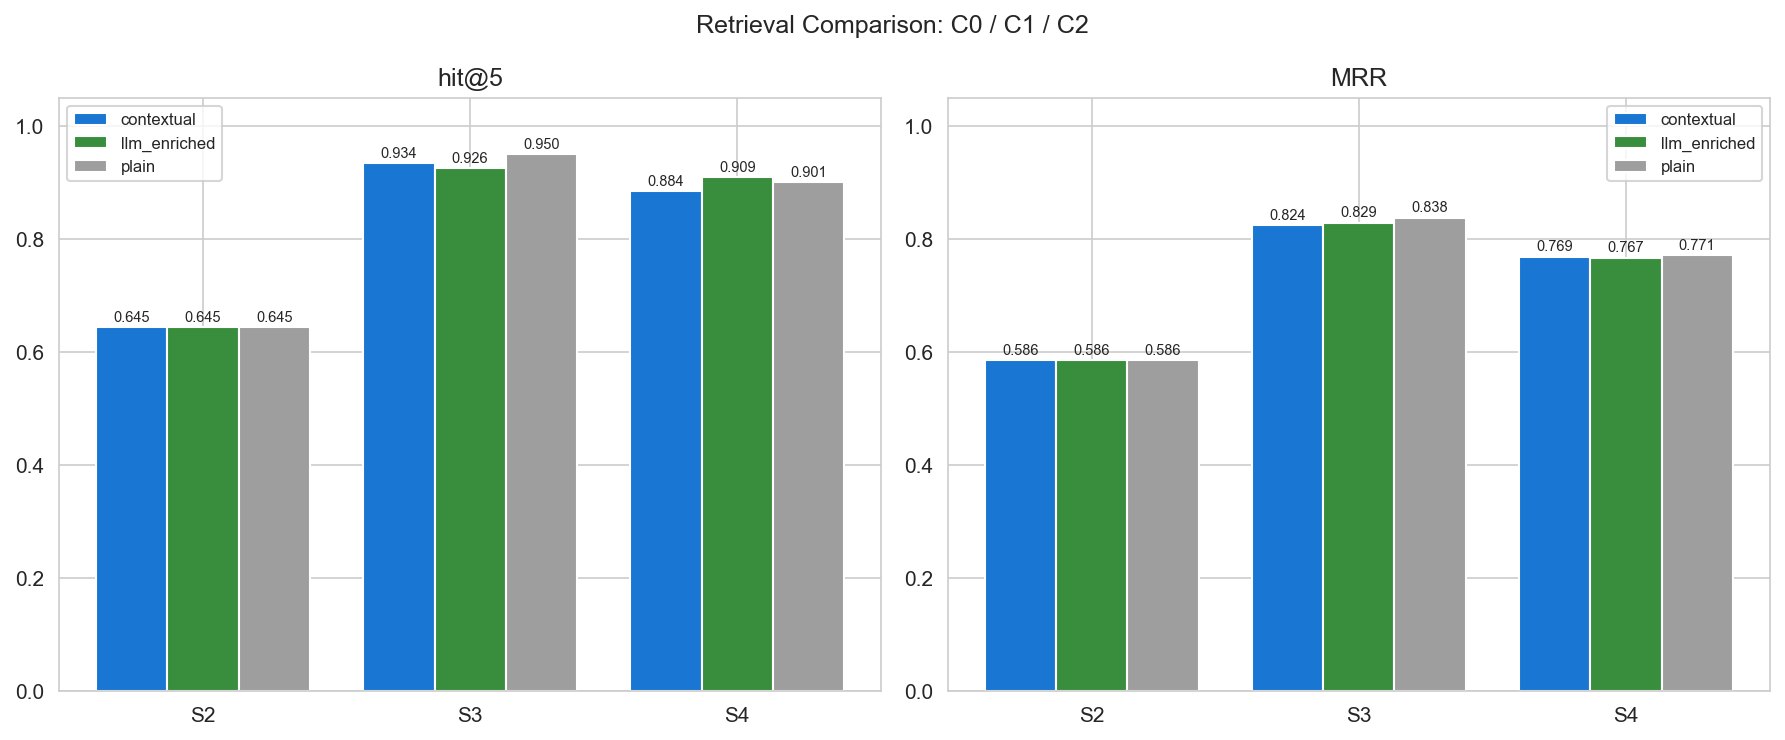

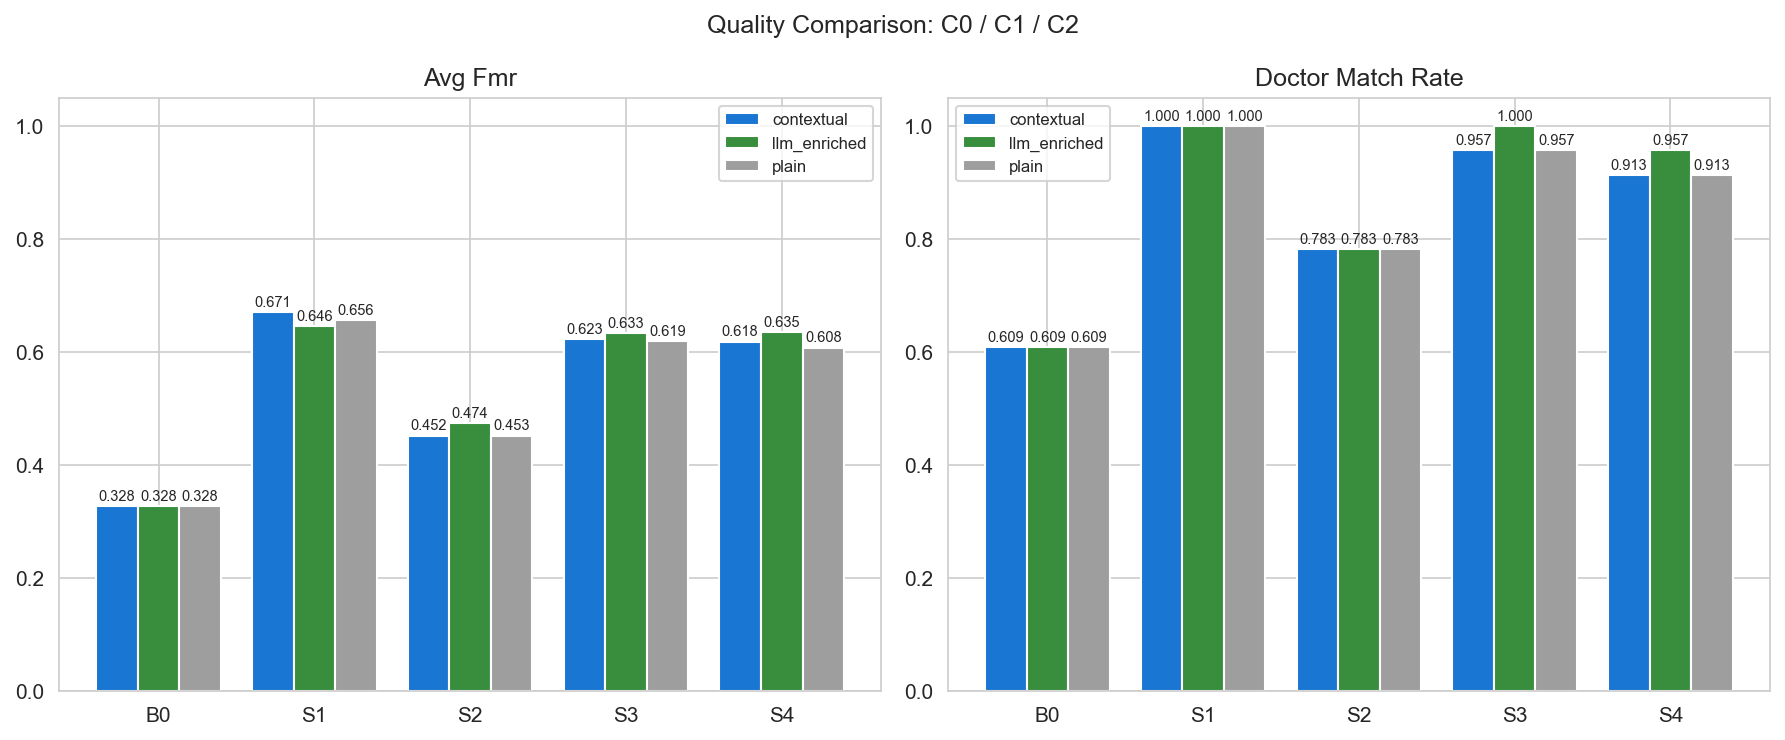

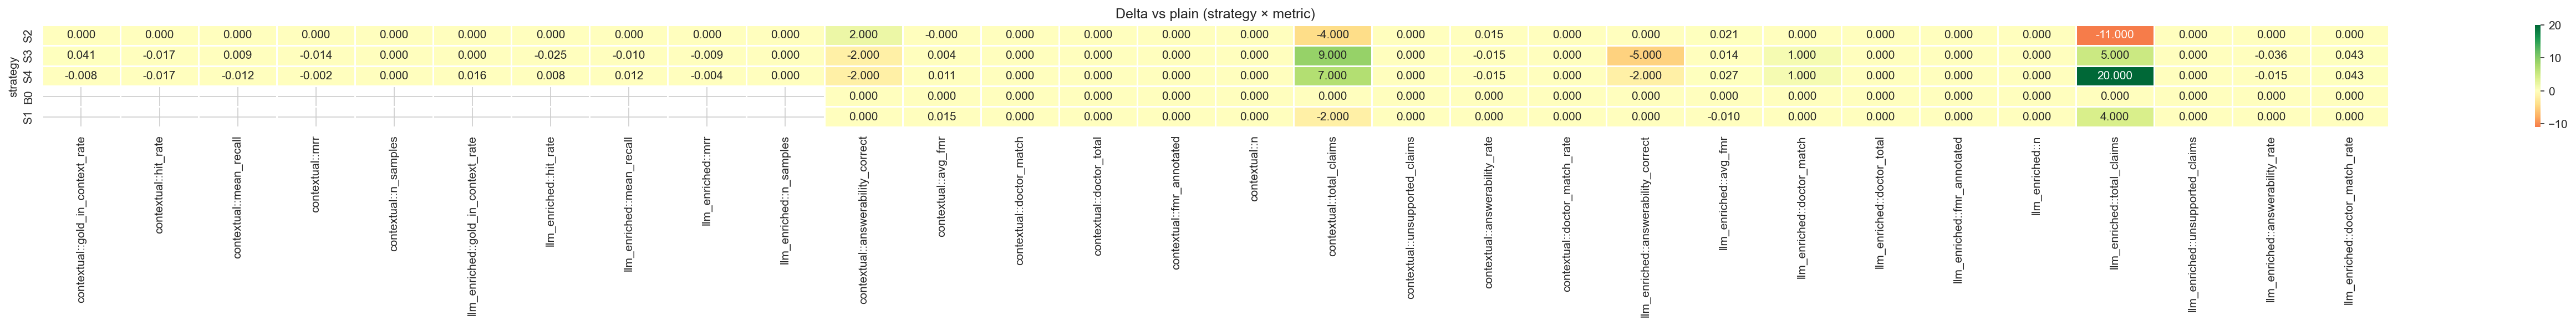

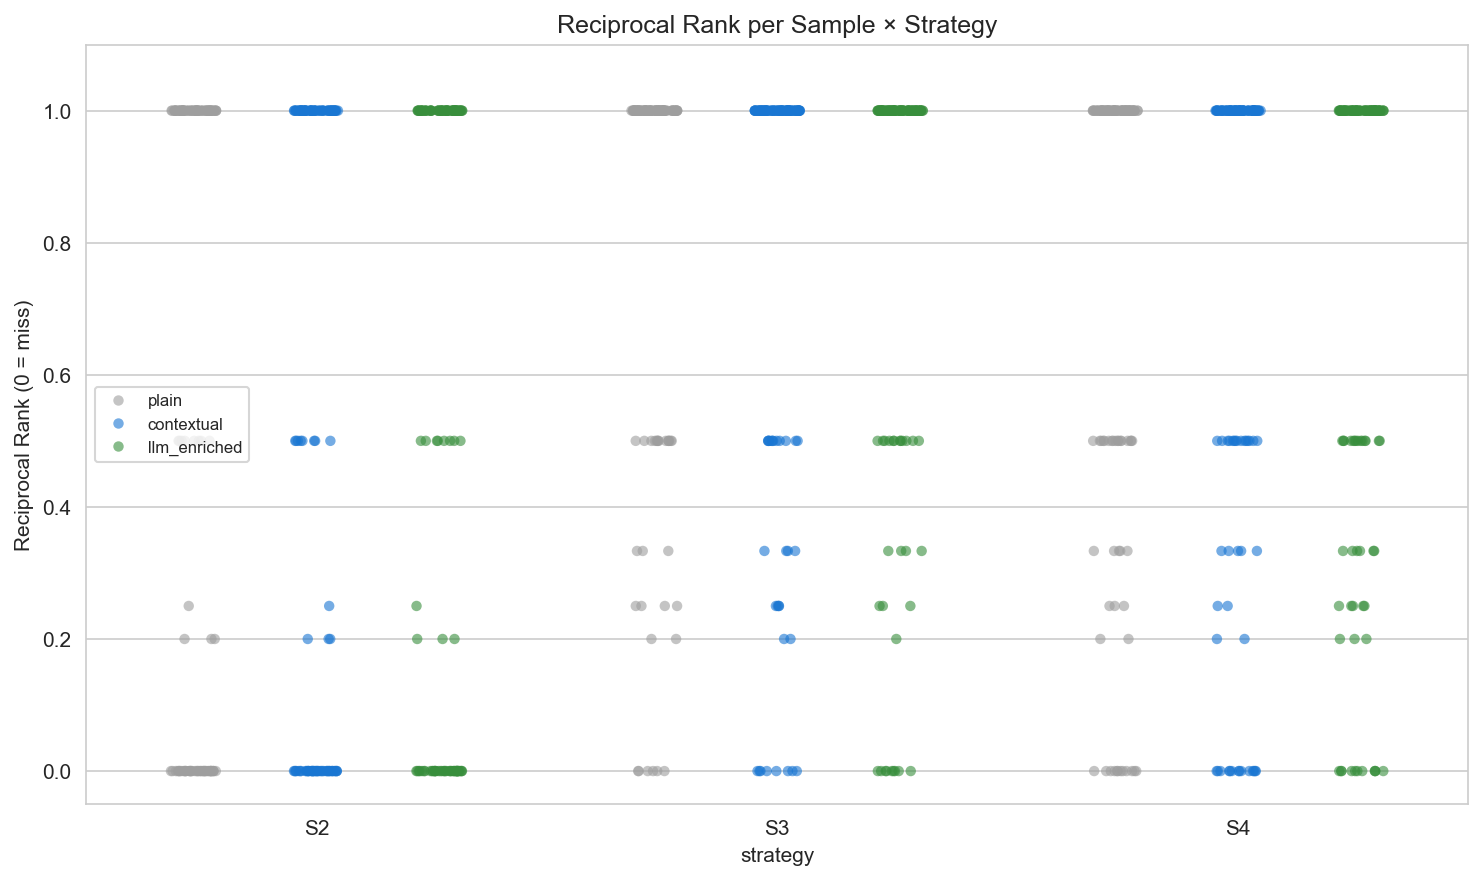


Сохранено 4 графиков в /Users/kazdoraw/developer/med-agent/study/d4/outputs/runs/20260419_235319/figures


In [32]:
from IPython.display import Image, display as ipy_display

# Destination sanity: figures должны уехать в run_dir текущего RUN_ID,
# а не в старый kernel-state.
assert run_paths.run_id == RUN_ID, (
    f"run_paths.run_id={run_paths.run_id!r} != RUN_ID={RUN_ID!r} — "
    "ячейка 3 (Run Config) не была перезапущена после смены RUN_ID."
)
print(f"Figures will be written to: {run_paths.figures_dir}")

figures = []

fig_ret = plot_retrieval_comparison(ret_table, run_paths)
figures.append(fig_ret)
ipy_display(Image(filename=str(fig_ret)))

fig_qual = plot_quality_comparison(det_table, run_paths)
figures.append(fig_qual)
ipy_display(Image(filename=str(fig_qual)))

fig_delta = plot_mode_deltas(ret_table, det_table, run_paths)
figures.append(fig_delta)
ipy_display(Image(filename=str(fig_delta)))

if not rank_df.empty:
    fig_rank = plot_rank_shift(rank_df, run_paths)
    figures.append(fig_rank)
    ipy_display(Image(filename=str(fig_rank)))

print(f"\nСохранено {len(figures)} графиков в {run_paths.figures_dir}")

## 7. Decision Memo

In [33]:
from IPython.display import Markdown

assert run_paths.run_id == RUN_ID, (
    f"run_paths.run_id={run_paths.run_id!r} != RUN_ID={RUN_ID!r} — "
    "ячейка 3 (Run Config) не была перезапущена после смены RUN_ID."
)
print(f"Memo will be written to: {run_paths.reports_dir}")

# run_meta уже собран и провалидирован в ячейке 9 (Load Reports).
# sig_df — из ячейки 13 (Statistical Significance); если её не запускали,
# memo будет сгенерирован без paired-блока (это ок, обратная совместимость).
memo_path = generate_stage2_memo(
    ret_table,
    det_table,
    gate,
    run_paths,
    figures,
    run_meta=run_meta,
    significance_df=sig_df if "sig_df" in globals() else None,
)
print(f"Memo: {memo_path}")
display(Markdown(memo_path.read_text(encoding="utf-8")))

Memo will be written to: /Users/kazdoraw/developer/med-agent/study/d4/outputs/runs/20260419_235319/reports
Memo: /Users/kazdoraw/developer/med-agent/study/d4/outputs/runs/20260419_235319/reports/stage2a_decision_memo.md


# Stage 2A Decision Memo

> **Source of truth**: `outputs/runs/20260419_235319/`

**Run ID**: `20260419_235319`  
**Timestamp**: 2026-04-20 14:13 UTC  
**Verdict**: **NEUTRAL**

---

## 1. Retrieval Comparison

| strategy   |   contextual::gold_in_context_rate |   contextual::hit_rate |   contextual::mean_recall |   contextual::mrr |   contextual::n_samples |   llm_enriched::gold_in_context_rate |   llm_enriched::hit_rate |   llm_enriched::mean_recall |   llm_enriched::mrr |   llm_enriched::n_samples |   plain::gold_in_context_rate |   plain::hit_rate |   plain::mean_recall |   plain::mrr |   plain::n_samples |   contextual::gold_in_context_rate::delta |   contextual::hit_rate::delta |   contextual::mean_recall::delta |   contextual::mrr::delta |   contextual::n_samples::delta |   llm_enriched::gold_in_context_rate::delta |   llm_enriched::hit_rate::delta |   llm_enriched::mean_recall::delta |   llm_enriched::mrr::delta |   llm_enriched::n_samples::delta |
|:-----------|-----------------------------------:|-----------------------:|--------------------------:|------------------:|------------------------:|-------------------------------------:|-------------------------:|----------------------------:|--------------------:|--------------------------:|------------------------------:|------------------:|---------------------:|-------------:|-------------------:|------------------------------------------:|------------------------------:|---------------------------------:|-------------------------:|-------------------------------:|--------------------------------------------:|--------------------------------:|-----------------------------------:|---------------------------:|---------------------------------:|
| S2         |                             0.5455 |                 0.6446 |                    0.5944 |            0.5855 |                121.0000 |                               0.5455 |                   0.6446 |                      0.5944 |              0.5855 |                  121.0000 |                        0.5455 |            0.6446 |               0.5944 |       0.5855 |           121.0000 |                                    0.0000 |                        0.0000 |                           0.0000 |                   0.0000 |                         0.0000 |                                      0.0000 |                          0.0000 |                             0.0000 |                     0.0000 |                           0.0000 |
| S3         |                             0.8678 |                 0.9339 |                    0.9056 |            0.8242 |                121.0000 |                               0.8264 |                   0.9256 |                      0.8864 |              0.8288 |                  121.0000 |                        0.8264 |            0.9504 |               0.8967 |       0.8380 |           121.0000 |                                    0.0414 |                       -0.0165 |                           0.0089 |                  -0.0138 |                         0.0000 |                                      0.0000 |                         -0.0248 |                            -0.0103 |                    -0.0092 |                           0.0000 |
| S4         |                             0.8099 |                 0.8843 |                    0.8547 |            0.7691 |                121.0000 |                               0.8347 |                   0.9091 |                      0.8795 |              0.7674 |                  121.0000 |                        0.8182 |            0.9008 |               0.8671 |       0.7712 |           121.0000 |                                   -0.0083 |                       -0.0165 |                          -0.0124 |                  -0.0021 |                         0.0000 |                                      0.0165 |                          0.0083 |                             0.0124 |                    -0.0038 |                           0.0000 |

## 2. Quality Comparison

| strategy   |   contextual::answerability_correct |   contextual::avg_fmr |   contextual::doctor_match |   contextual::doctor_total |   contextual::fmr_annotated |   contextual::n |   contextual::total_claims |   contextual::unsupported_claims |   llm_enriched::answerability_correct |   llm_enriched::avg_fmr |   llm_enriched::doctor_match |   llm_enriched::doctor_total |   llm_enriched::fmr_annotated |   llm_enriched::n |   llm_enriched::total_claims |   llm_enriched::unsupported_claims |   plain::answerability_correct |   plain::avg_fmr |   plain::doctor_match |   plain::doctor_total |   plain::fmr_annotated |   plain::n |   plain::total_claims |   plain::unsupported_claims |   contextual::answerability_rate |   contextual::doctor_match_rate |   llm_enriched::answerability_rate |   llm_enriched::doctor_match_rate |   plain::answerability_rate |   plain::doctor_match_rate |   contextual::answerability_correct::delta |   contextual::avg_fmr::delta |   contextual::doctor_match::delta |   contextual::doctor_total::delta |   contextual::fmr_annotated::delta |   contextual::n::delta |   contextual::total_claims::delta |   contextual::unsupported_claims::delta |   contextual::answerability_rate::delta |   contextual::doctor_match_rate::delta |   llm_enriched::answerability_correct::delta |   llm_enriched::avg_fmr::delta |   llm_enriched::doctor_match::delta |   llm_enriched::doctor_total::delta |   llm_enriched::fmr_annotated::delta |   llm_enriched::n::delta |   llm_enriched::total_claims::delta |   llm_enriched::unsupported_claims::delta |   llm_enriched::answerability_rate::delta |   llm_enriched::doctor_match_rate::delta |
|:-----------|------------------------------------:|----------------------:|---------------------------:|---------------------------:|----------------------------:|----------------:|---------------------------:|---------------------------------:|--------------------------------------:|------------------------:|-----------------------------:|-----------------------------:|------------------------------:|------------------:|-----------------------------:|-----------------------------------:|-------------------------------:|-----------------:|----------------------:|----------------------:|-----------------------:|-----------:|----------------------:|----------------------------:|---------------------------------:|--------------------------------:|-----------------------------------:|----------------------------------:|----------------------------:|---------------------------:|-------------------------------------------:|-----------------------------:|----------------------------------:|----------------------------------:|-----------------------------------:|-----------------------:|----------------------------------:|----------------------------------------:|----------------------------------------:|---------------------------------------:|---------------------------------------------:|-------------------------------:|------------------------------------:|------------------------------------:|-------------------------------------:|-------------------------:|------------------------------------:|------------------------------------------:|------------------------------------------:|-----------------------------------------:|
| B0         |                            117.0000 |                0.3280 |                    14.0000 |                    23.0000 |                    121.0000 |        137.0000 |                   282.0000 |                           0.0000 |                              117.0000 |                  0.3280 |                      14.0000 |                      23.0000 |                      121.0000 |          137.0000 |                     282.0000 |                             0.0000 |                       117.0000 |           0.3280 |               14.0000 |               23.0000 |               121.0000 |   137.0000 |              282.0000 |                      0.0000 |                           0.8540 |                          0.6087 |                             0.8540 |                            0.6087 |                      0.8540 |                     0.6087 |                                     0.0000 |                       0.0000 |                            0.0000 |                            0.0000 |                             0.0000 |                 0.0000 |                            0.0000 |                                  0.0000 |                                  0.0000 |                                 0.0000 |                                       0.0000 |                         0.0000 |                              0.0000 |                              0.0000 |                               0.0000 |                   0.0000 |                              0.0000 |                                    0.0000 |                                    0.0000 |                                   0.0000 |
| S1         |                            134.0000 |                0.6711 |                    23.0000 |                    23.0000 |                    121.0000 |        137.0000 |                   317.0000 |                           0.0000 |                              134.0000 |                  0.6460 |                      23.0000 |                      23.0000 |                      121.0000 |          137.0000 |                     323.0000 |                             0.0000 |                       134.0000 |           0.6562 |               23.0000 |               23.0000 |               121.0000 |   137.0000 |              319.0000 |                      0.0000 |                           0.9781 |                          1.0000 |                             0.9781 |                            1.0000 |                      0.9781 |                     1.0000 |                                     0.0000 |                       0.0149 |                            0.0000 |                            0.0000 |                             0.0000 |                 0.0000 |                           -2.0000 |                                  0.0000 |                                  0.0000 |                                 0.0000 |                                       0.0000 |                        -0.0102 |                              0.0000 |                              0.0000 |                               0.0000 |                   0.0000 |                              4.0000 |                                    0.0000 |                                    0.0000 |                                   0.0000 |
| S2         |                            111.0000 |                0.4523 |                    18.0000 |                    23.0000 |                    121.0000 |        137.0000 |                   302.0000 |                           0.0000 |                              109.0000 |                  0.4738 |                      18.0000 |                      23.0000 |                      121.0000 |          137.0000 |                     295.0000 |                             0.0000 |                       109.0000 |           0.4525 |               18.0000 |               23.0000 |               121.0000 |   137.0000 |              306.0000 |                      0.0000 |                           0.8102 |                          0.7826 |                             0.7956 |                            0.7826 |                      0.7956 |                     0.7826 |                                     2.0000 |                      -0.0002 |                            0.0000 |                            0.0000 |                             0.0000 |                 0.0000 |                           -4.0000 |                                  0.0000 |                                  0.0146 |                                 0.0000 |                                       0.0000 |                         0.0213 |                              0.0000 |                              0.0000 |                               0.0000 |                   0.0000 |                            -11.0000 |                                    0.0000 |                                    0.0000 |                                   0.0000 |
| S3         |                            132.0000 |                0.6232 |                    22.0000 |                    23.0000 |                    121.0000 |        137.0000 |                   336.0000 |                           0.0000 |                              129.0000 |                  0.6333 |                      23.0000 |                      23.0000 |                      121.0000 |          137.0000 |                     332.0000 |                             0.0000 |                       134.0000 |           0.6190 |               22.0000 |               23.0000 |               121.0000 |   137.0000 |              327.0000 |                      0.0000 |                           0.9635 |                          0.9565 |                             0.9416 |                            1.0000 |                      0.9781 |                     0.9565 |                                    -2.0000 |                       0.0042 |                            0.0000 |                            0.0000 |                             0.0000 |                 0.0000 |                            9.0000 |                                  0.0000 |                                 -0.0146 |                                 0.0000 |                                      -5.0000 |                         0.0143 |                              1.0000 |                              0.0000 |                               0.0000 |                   0.0000 |                              5.0000 |                                    0.0000 |                                   -0.0365 |                                   0.0435 |
| S4         |                            128.0000 |                0.6182 |                    21.0000 |                    23.0000 |                    121.0000 |        137.0000 |                   314.0000 |                           0.0000 |                              128.0000 |                  0.6350 |                      22.0000 |                      23.0000 |                      121.0000 |          137.0000 |                     327.0000 |                             0.0000 |                       130.0000 |           0.6076 |               21.0000 |               23.0000 |               121.0000 |   137.0000 |              307.0000 |                      0.0000 |                           0.9343 |                          0.9130 |                             0.9343 |                            0.9565 |                      0.9489 |                     0.9130 |                                    -2.0000 |                       0.0106 |                            0.0000 |                            0.0000 |                             0.0000 |                 0.0000 |                            7.0000 |                                  0.0000 |                                 -0.0146 |                                 0.0000 |                                      -2.0000 |                         0.0274 |                              1.0000 |                              0.0000 |                               0.0000 |                   0.0000 |                             20.0000 |                                    0.0000 |                                   -0.0146 |                                   0.0435 |

## 3. Statistical Significance (per-sample, paired)

Paired bootstrap-CI и тесты по per-sample артефактам прогона (`report.json` → `rank_analysis`, `*.jsonl`, eval_set gold). FMR здесь **не** представлен: `save_judge_scores` в pipeline пока не вызывается, per-sample judge-оценки не сохранены (см. `d4/analysis/significance.py`).

★ рядом со строкой — CI парной разности не пересекает 0 (слабый прокси значимости, без поправок на множественные сравнения).

### mrr  (n=121)

| mode | mean | CI mean | Δ vs baseline | CI Δ | p | test | sig |
|---|---|---|---|---|---|---|---|
| `plain` (baseline) | 0.8380 | [+0.7777, +0.8880] | — | — | — | — | — |
| `contextual` | 0.8242 | [+0.7625, +0.8774] | -0.0138 | [-0.0416, +0.0124] | 0.303 | wilcoxon |  |
| `llm_enriched` | 0.8288 | [+0.7689, +0.8822] | -0.0092 | [-0.0479, +0.0293] | 0.557 | wilcoxon |  |

### hit_rate  (n=121)

| mode | mean | CI mean | Δ vs baseline | CI Δ | p | test | sig |
|---|---|---|---|---|---|---|---|
| `plain` (baseline) | 0.9504 | [+0.9091, +0.9835] | — | — | — | — | — |
| `contextual` | 0.9339 | [+0.8843, +0.9752] | -0.0165 | [-0.0496, +0.0165] | 0.625 | mcnemar |  |
| `llm_enriched` | 0.9256 | [+0.8760, +0.9669] | -0.0248 | [-0.0661, +0.0165] | 0.453 | mcnemar |  |

### answerability_correct  (n=137)

| mode | mean | CI mean | Δ vs baseline | CI Δ | p | test | sig |
|---|---|---|---|---|---|---|---|
| `plain` (baseline) | 0.9781 | [+0.9489, +1.0000] | — | — | — | — | — |
| `contextual` | 0.9635 | [+0.9270, +0.9927] | -0.0146 | [-0.0365, +0.0000] | 0.500 | mcnemar |  |
| `llm_enriched` | 0.9416 | [+0.8978, +0.9781] | -0.0365 | [-0.0730, -0.0073] | 0.062 | mcnemar | ★ |

### doctor_match  (n=23)

| mode | mean | CI mean | Δ vs baseline | CI Δ | p | test | sig |
|---|---|---|---|---|---|---|---|
| `plain` (baseline) | 0.9565 | [+0.8696, +1.0000] | — | — | — | — | — |
| `contextual` | 0.9565 | [+0.8696, +1.0000] | +0.0000 | [+0.0000, +0.0000] | 1.000 | mcnemar |  |
| `llm_enriched` | 1.0000 | [+1.0000, +1.0000] | +0.0435 | [+0.0000, +0.1304] | 1.000 | mcnemar |  |

## 4. Decision Gate

**Verdict**: `neutral`  
**Recommendation**: FMR немного подрос, но retrieval просел — сигнал противоречивый. Без bootstrap-CI / paired-теста выигрыш FMR может быть шумом. Прогоните hard и blind eval-сеты, чтобы исключить переобучение под dev-распределение.

### Signals

- contextual: MRR drop -0.014 ≤ порог
- llm_enriched: hit_rate drop -0.025 ≤ порог
- llm_enriched: FMR improvement +0.014

## 5. Figures

![retrieval_comparison](figures/retrieval_comparison.png)
![quality_comparison](figures/quality_comparison.png)
![mode_deltas](figures/mode_deltas.png)
![rank_shift](figures/rank_shift.png)

## 6. Artifact Index

| Категория | Файл |
|-----------|------|
| meta | `config_snapshot.yaml` |
| figure | `figures/mode_deltas.png` |
| figure | `figures/quality_comparison.png` |
| figure | `figures/rank_shift.png` |
| figure | `figures/retrieval_comparison.png` |
| result | `full_dev_contextual.jsonl` |
| report | `full_dev_contextual.report.json` |
| result | `full_dev_llm_enriched.jsonl` |
| report | `full_dev_llm_enriched.report.json` |
| result | `full_dev_plain.jsonl` |
| report | `full_dev_plain.report.json` |
| meta | `manifest.json` |
| report | `reports/stage2a_decision_memo.md` |


## 8. Artifact Index

In [34]:
import pandas as pd

artifacts = list_run_artifacts(run_paths)
if artifacts:
    df_art = pd.DataFrame(artifacts, columns=["category", "path"])
    df_art["file"] = df_art["path"].apply(lambda p: p.name)
    display(df_art[["category", "file"]])
else:
    print("Нет артефактов в run_dir")

,category,file
0,meta,config_snapshot.yaml
1,figure,mode_deltas.png
2,figure,quality_comparison.png
3,figure,rank_shift.png
4,figure,retrieval_comparison.png
5,result,full_dev_contextual.jsonl
6,report,full_dev_contextual.report.json
7,result,full_dev_llm_enriched.jsonl
8,report,full_dev_llm_enriched.report.json
9,result,full_dev_plain.jsonl
